In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,confusion_matrix,classification_report,roc_curve,auc 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the dataset
data = pd.read_csv('dataset/Churn_Modelling.csv')

# Display the first few rows of the dataset
print(data.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [4]:
df_cleaned = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print(df_cleaned.head())

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


In [5]:
y = df_cleaned['Exited']
X_raw = df_cleaned.drop('Exited', axis=1)

X_encoded = pd.get_dummies(X_raw, columns=['Geography', 'Gender'], drop_first=True)
print(X_encoded.head())

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
0               1        101348.88              False            False   
1               1        112542.58              False             True   
2               0        113931.57              False            False   
3               0         93826.63              False            False   
4               1         79084.10              False             True   

   Gender_Male  
0        False  
1        False  
2        False  
3        False  
4        False  


In [6]:
# Feature Scaling and PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)
print(f'Original shape: {X_scaled.shape}, PCA shape: {X_pca.shape}')


Original shape: (10000, 11), PCA shape: (10000, 10)


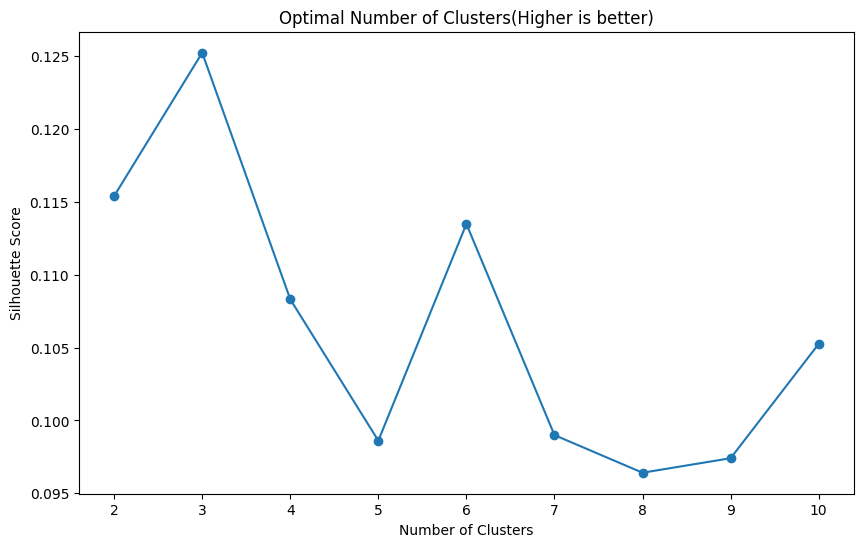

Optimal number of clusters: 3


In [7]:
# Calculate the Silhouette Score for KMeans clustering
sil_score = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, cluster_labels)
    sil_score.append(score)

# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), sil_score, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Optimal Number of Clusters(Higher is better)')
plt.show()

best_k = range(2, 11)[np.argmax(sil_score)]
print(f'Optimal number of clusters: {best_k}')

In [8]:
final_kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
customers_clustered = final_kmeans.fit_predict(X_pca)

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_pca['Cluster'] = customers_clustered

X_train, X_test, y_train, y_test = train_test_split(df_pca, y, test_size=0.2, random_state=42)

In [9]:
print(df_pca.head())
print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, y_train shape: {y_train.shape}, y_test shape: {y_test.shape}')



        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -0.526819 -0.376014  0.968160 -0.386196 -1.005841 -0.237602 -0.310796   
1 -0.726318 -2.095834  0.727685 -2.072670 -0.178328 -0.248250 -0.002318   
2  0.009900  2.116374 -0.149913 -0.261127 -1.535011  1.078477 -0.024953   
3 -0.993175  0.933032  0.792027 -2.028063  0.259603 -1.276548 -0.182550   
4 -0.324849 -2.000789  0.808253 -0.073848  0.672545 -0.732199 -2.214769   

        PC8       PC9      PC10  Cluster  
0  1.100555  0.705059 -1.461480        0  
1  0.025009  0.797570  0.604566        1  
2 -0.468409 -0.142878  1.124523        0  
3 -0.429849 -0.758804 -0.760618        0  
4  1.254449  0.329764  0.805544        1  
X_train shape: (8000, 11), X_test shape: (2000, 11), y_train shape: (8000,), y_test shape: (2000,)


In [10]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
import numpy as np

In [12]:
def Objective(trial):
    C = trial.suggest_loguniform('C', 1e-3, 1e1)
    gamma = trial.suggest_loguniform('gamma', 1e-3, 1e-1)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    
    
    model = SVC(C=C, gamma=gamma, kernel=kernel, random_state=42)

    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()
    
    return score

In [13]:
print('Firing the Optimization Engine...')
study = optuna.create_study(direction='maximize')
study.optimize(Objective, n_trials=30)
print('Best Hyperparameters:', study.best_params)

best_params = study.best_params

best_model = SVC(C=best_params['C'], gamma=best_params['gamma'], kernel=best_params['kernel'], random_state=42)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[I 2026-06-16 21:35:57,467] A new study created in memory with name: no-name-7e33c62c-0b3f-4eed-afa7-296c6cc460dc


Firing the Optimization Engine...


[I 2026-06-16 21:36:06,037] Trial 0 finished with value: 0.0 and parameters: {'C': 0.0049665121823120545, 'gamma': 0.0033479523706743805, 'kernel': 'rbf'}. Best is trial 0 with value: 0.0.
[I 2026-06-16 21:36:12,561] Trial 1 finished with value: 0.0 and parameters: {'C': 8.656244938224596, 'gamma': 0.032770079901802744, 'kernel': 'linear'}. Best is trial 0 with value: 0.0.
[I 2026-06-16 21:36:18,338] Trial 2 finished with value: 0.0 and parameters: {'C': 0.009296860597938172, 'gamma': 0.0014295350497960534, 'kernel': 'linear'}. Best is trial 0 with value: 0.0.
[I 2026-06-16 21:36:23,390] Trial 3 finished with value: 0.0 and parameters: {'C': 0.0021673096280660346, 'gamma': 0.005891536166072607, 'kernel': 'linear'}. Best is trial 0 with value: 0.0.
[I 2026-06-16 21:36:29,844] Trial 4 finished with value: 0.0 and parameters: {'C': 2.824852467775595, 'gamma': 0.007896158489777877, 'kernel': 'linear'}. Best is trial 0 with value: 0.0.
[I 2026-06-16 21:36:35,209] Trial 5 finished with value

Best Hyperparameters: {'C': 4.4166975322148465, 'gamma': 0.0631733719910178, 'kernel': 'rbf'}
[[1560   47]
 [ 233  160]]


In [14]:
print("Test set accuracy:", best_model.score(X_test, y_test))

Test set accuracy: 0.86


In [15]:
import joblib

best_model_full = SVC(
    C=best_params['C'],
    gamma=best_params['gamma'],
    kernel=best_params['kernel'],
    probability=True,
    random_state=42
)

best_model_full.fit(df_pca, y)

# Freeze the entire pipeline architecture to local drive
joblib.dump(scaler, 'bank_scaler.pkl')
joblib.dump(pca, 'bank_pca.pkl')
joblib.dump(final_kmeans, 'bank_kmeans.pkl')
joblib.dump(best_model_full, 'bank_svm_model.pkl')

print("All pipeline artifacts successfully exported. Ready for UI integration.")

All pipeline artifacts successfully exported. Ready for UI integration.
